In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
import kagglehub
import os

# Download latest version
path = kagglehub.dataset_download("dgomonov/new-york-city-airbnb-open-data")

print("Path to dataset files:", path)
ab_nyc=os.path.join(path,"AB_NYC_2019.csv")
data_df=pd.read_csv(ab_nyc)
data_df.head()


Using Colab cache for faster access to the 'new-york-city-airbnb-open-data' dataset.
Path to dataset files: /kaggle/input/new-york-city-airbnb-open-data


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [ ]:
data_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

In [ ]:
data_df.describe()

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,4.889500e+04,4.889500e+04,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,38843.000000,48895.000000,48895.000000
mean,1.901714e+07,6.762001e+07,40.728949,-73.952170,152.720687,7.029962,23.274466,1.373221,7.143982,112.781327
std,1.098311e+07,7.861097e+07,0.054530,0.046157,240.154170,20.510550,44.550582,1.680442,32.952519,131.622289
min,2.539000e+03,2.438000e+03,40.499790,-74.244420,0.000000,1.000000,0.000000,0.010000,1.000000,0.000000
25%,9.471945e+06,7.822033e+06,40.690100,-73.983070,69.000000,1.000000,1.000000,0.190000,1.000000,0.000000
50%,1.967728e+07,3.079382e+07,40.723070,-73.955680,106.000000,3.000000,5.000000,0.720000,1.000000,45.000000
75%,2.915218e+07,1.074344e+08,40.763115,-73.936275,175.000000,5.000000,24.000000,2.020000,2.000000,227.000000
max,3.648724e+07,2.743213e+08,40.913060,-73.712990,10000.000000,1250.000000,629.000000,58.500000,327.000000,365.000000


In [ ]:
data_df.shape

(48895, 16)

In [ ]:
data_df.isnull().sum()

,0
id,0
name,16
host_id,0
host_name,21
neighbourhood_group,0
neighbourhood,0
latitude,0
longitude,0
room_type,0
price,0


In [ ]:
data_df.duplicated().sum()

np.int64(0)

In [ ]:
# sns.pairplot(data_df,hue='room_type')

<Axes: xlabel='room_type', ylabel='count'>

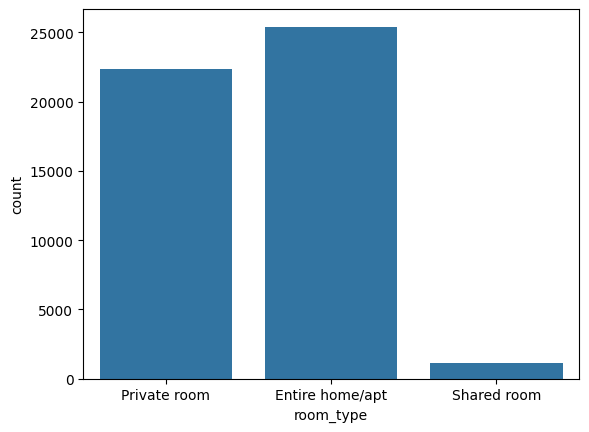

In [ ]:
sns.countplot(x='room_type',data=data_df)

In [ ]:
number_col=data_df.select_dtypes(include=np.number).drop(columns=['id','host_id']).columns
number_col

Index(['latitude', 'longitude', 'price', 'minimum_nights', 'number_of_reviews',
       'reviews_per_month', 'calculated_host_listings_count',
       'availability_365'],
      dtype='object')

array([[<Axes: title={'center': 'latitude'}>,
        <Axes: title={'center': 'longitude'}>,
        <Axes: title={'center': 'price'}>],
       [<Axes: title={'center': 'minimum_nights'}>,
        <Axes: title={'center': 'number_of_reviews'}>,
        <Axes: title={'center': 'reviews_per_month'}>],
       [<Axes: title={'center': 'calculated_host_listings_count'}>,
        <Axes: title={'center': 'availability_365'}>, <Axes: >]],
      dtype=object)

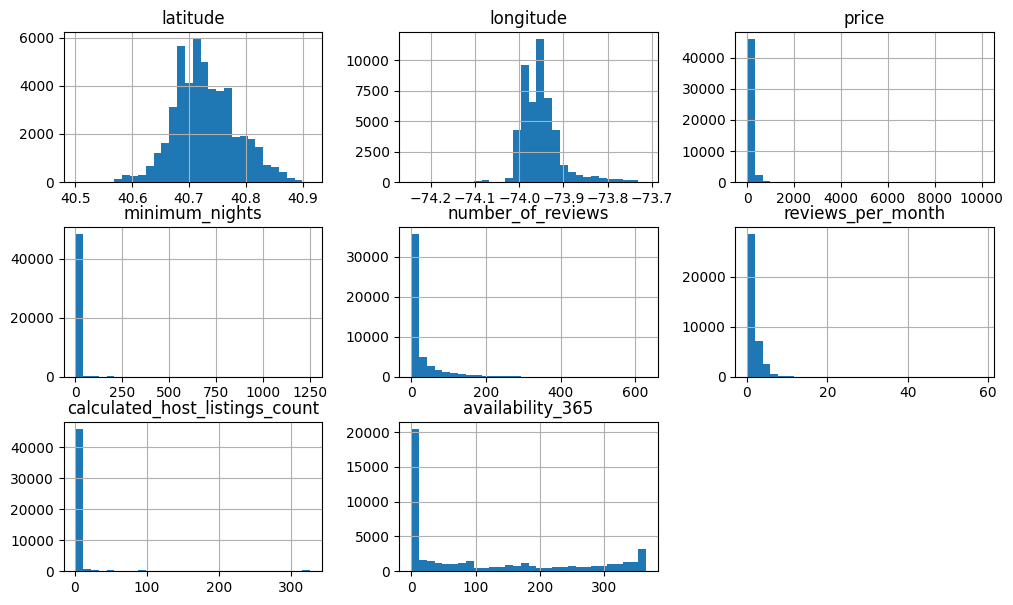

In [ ]:
data_df[number_col].hist(bins=30,figsize=(12,7))

In [ ]:
# Show skewness for all numeric features
print(data_df[number_col].skew(numeric_only=True))


latitude                           0.237167
longitude                          1.284210
price                             19.118939
minimum_nights                    21.827275
number_of_reviews                  3.690635
reviews_per_month                  3.130189
calculated_host_listings_count     7.933174
availability_365                   0.763408
dtype: float64


<Axes: ylabel='Count'>

/usr/local/lib/python3.12/dist-packages/IPython/core/events.py:89: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


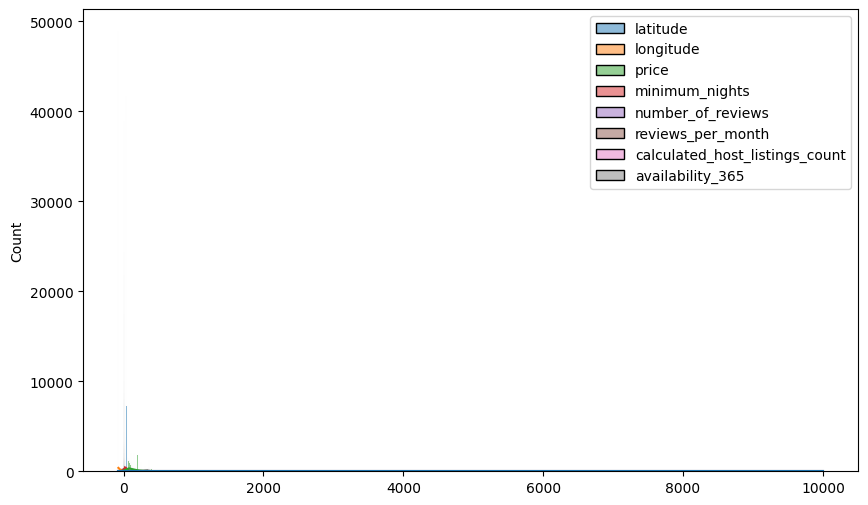

In [ ]:
plt.figure(figsize=(10,6))
sns.histplot(data_df[number_col], kde=True)


<Axes: >

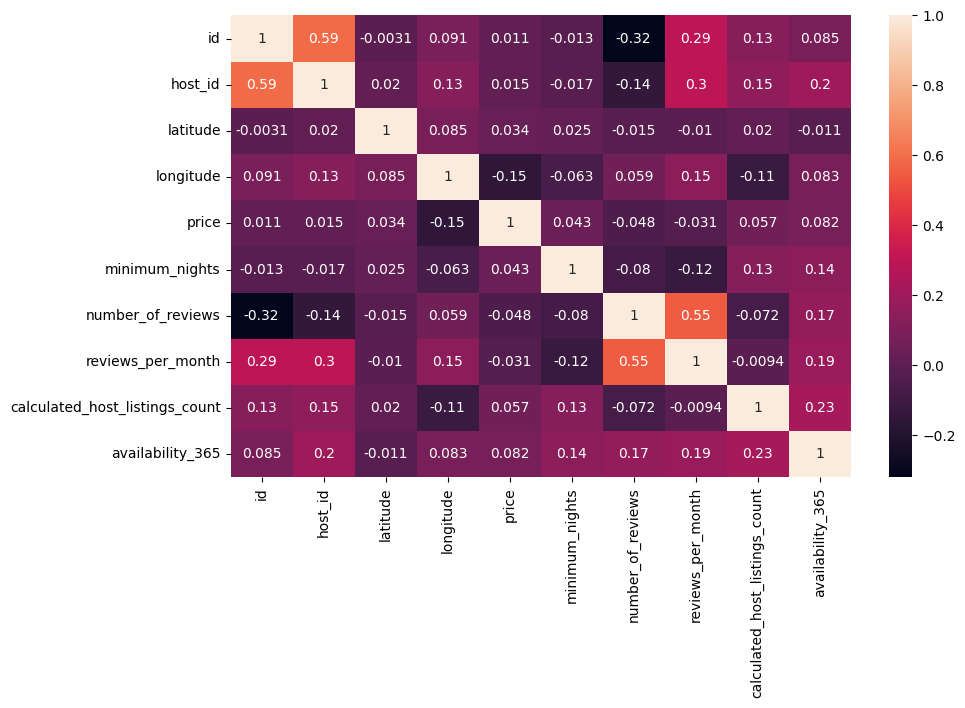

In [ ]:
plt.figure(figsize=(10,6))
sns.heatmap(data_df.corr(numeric_only=True), annot=True)

<Axes: xlabel='room_type', ylabel='price'>

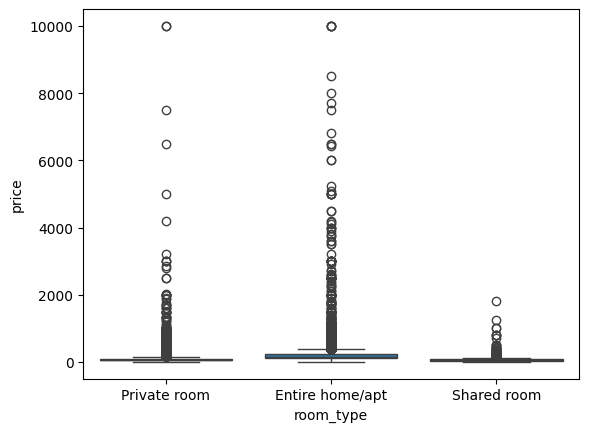

In [ ]:
sns.boxplot(x='room_type',y='price',data=data_df)

<Axes: xlabel='room_type', ylabel='minimum_nights'>

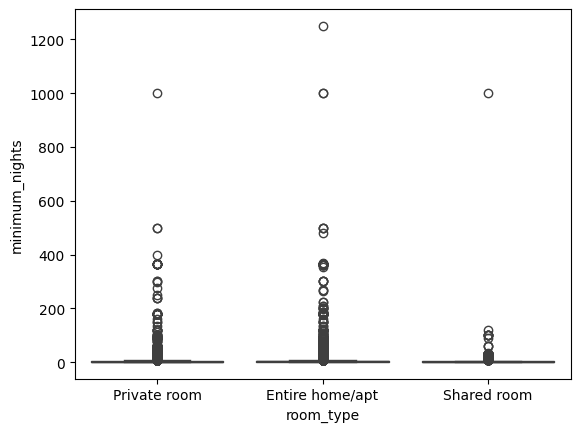

In [ ]:
sns.boxplot(x='room_type',y='minimum_nights',data=data_df)

In [5]:
data_df.columns

Index(['id', 'name', 'host_id', 'host_name', 'neighbourhood_group',
       'neighbourhood', 'latitude', 'longitude', 'room_type', 'price',
       'minimum_nights', 'number_of_reviews', 'last_review',
       'reviews_per_month', 'calculated_host_listings_count',
       'availability_365'],
      dtype='object')

In [6]:
clean_df = data_df.drop(columns=['id', 'name', 'host_id', 'host_name', 'last_review'])


In [7]:
clean_df['reviews_per_month'].fillna(0, inplace=True)

/tmp/ipykernel_1278/3571541866.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  clean_df['reviews_per_month'].fillna(0, inplace=True)


In [8]:
# Calculate the 99th percentile thresholds
price_bound = clean_df['price'].quantile(0.99)
minimum_nights_bound = clean_df['minimum_nights'].quantile(0.99)
clean_df['price'] = clean_df['price'].clip(upper=price_bound)
clean_df['minimum_nights'] = clean_df['minimum_nights'].clip(upper=minimum_nights_bound)


In [9]:
X=clean_df.drop(columns=['room_type'])
y=clean_df['room_type']

In [ ]:
clean_df.columns

Index(['neighbourhood_group', 'neighbourhood', 'latitude', 'longitude',
       'room_type', 'price', 'minimum_nights', 'number_of_reviews',
       'reviews_per_month', 'calculated_host_listings_count',
       'availability_365'],
      dtype='object')

In [ ]:
clean_df.shape

(48895, 11)

In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.7, random_state=42)

catogrical_col=['neighbourhood_group', 'neighbourhood']
numerical_col=clean_df.select_dtypes(include=np.number).drop(columns=['latitude','longitude']).columns
spital_col=['latitude','longitude']
numerical_col

Index(['price', 'minimum_nights', 'number_of_reviews', 'reviews_per_month',
       'calculated_host_listings_count', 'availability_365'],
      dtype='object')

In [11]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler,PowerTransformer,RobustScaler
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

In [12]:
catogarical_pipe=Pipeline(steps=[
    ('simple_imputer',SimpleImputer(strategy='most_frequent')),
    ('onehot_encoder',OneHotEncoder(handle_unknown='ignore'))
])
numeric_pipe=Pipeline(steps=[
    ('simple_imputer',SimpleImputer(strategy='median')),
    ('robust',RobustScaler()),
    ('power_trans',PowerTransformer(method='yeo-johnson')),
    ('standar_scal',StandardScaler())
])
spital_pipe=Pipeline(steps=[
    ('simple_imputer',SimpleImputer(strategy='median')),
    ('standar_scal',StandardScaler())
])

preprocesor=ColumnTransformer(transformers=[
  ('catogarical_transformer',catogarical_pipe,catogrical_col),
  ('numerical_transformer',numeric_pipe,numerical_col),
  ('spital_transformer',spital_pipe,spital_col)
])

In [13]:
import warnings
warnings.filterwarnings('ignore')

In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier , GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score,f1_score,confusion_matrix

In [15]:
models={
    "Logistic Regression":LogisticRegression(class_weight='balanced',random_state=42),
    "Random Forest":RandomForestClassifier(class_weight='balanced',random_state=42),
    "Decision Tree":DecisionTreeClassifier(class_weight='balanced',random_state=42),
    "Gradient Boosting":GradientBoostingClassifier()
}

In [ ]:
for name,model in models.items():
  Pipe=Pipeline(steps=[
      ('preprocesor',preprocesor),
      ('model_name',model)
  ])
  accuracy=cross_val_score(Pipe,X_train,y_train,cv=3,scoring='accuracy',error_score='raise')
  f1=cross_val_score(Pipe,X_train,y_train,cv=3,scoring='f1_macro',error_score='raise')
  print(f"model:{name} :- f1_score:{f1.mean():.3f} and accuracy:{accuracy.mean():.3f}")

model:Logistic Regression :- f1_score:0.575 and accuracy:0.727
model:Random Forest :- f1_score:0.713 and accuracy:0.851
model:Decision Tree :- f1_score:0.646 and accuracy:0.782
model:Gradient Boosting :- f1_score:0.705 and accuracy:0.850


In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier

best_pipeline=Pipeline(steps=[
    ('preprocessor',preprocesor),
    ('model',RandomForestClassifier(class_weight='balanced'))
])

param_dist = {
    'model__n_estimators': [100, 200],
    'model__max_features': ['sqrt', 'log2'],
    'model__max_depth': [10, 20, 30, 50, None],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4],
    'model__bootstrap': [True]
}

cv = RandomizedSearchCV(
    estimator = best_pipeline,
    param_distributions = param_dist,
    n_iter=150,
    cv=5,
    random_state=42,
    scoring='f1_macro'
)

cv.fit(X_train, y_train)

print("Best parameters found:", cv.best_params_)
print("Best score:", cv.best_score_)

Best parameters found: {'model__n_estimators': 200, 'model__min_samples_split': 5, 'model__min_samples_leaf': 2, 'model__max_features': 'sqrt', 'model__max_depth': None, 'model__bootstrap': True}
Best score: 0.7372836313788615


In [ ]:
best_pipeline=cv.best_estimator_
y_pred= best_pipeline.predict(X_test)
y_pred_train= best_pipeline.predict(X_train)

print(f"Accuracy (Train): {accuracy_score(y_train, y_pred_train):.3f}")
print(f"Accuracy (Test): {accuracy_score(y_test, y_pred):.3f}")
print(f"F1_Score (Macro): {f1_score(y_test, y_pred, average='macro'):.3f}")

In [ ]:
sns.heatmap(confusion_matrix(y_test,y_pred),annot=True,fmt=".2f"
,xticklabels=best_pipeline.classes_,yticklabels=best_pipeline.classes_)

In [16]:
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, f1_score

# XGBoost requires numerical labels
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

xgboost_model = Pipeline(steps=[
    ('preprocessor', preprocesor),
    ('xgboost_model', XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1
    ))
])

# Fit the model using encoded labels
xg_model = xgboost_model.fit(X_train, y_train_encoded)

xgb_pred = xgboost_model.predict(X_test)
xgb_pred_train = xgboost_model.predict(X_train)

xgb_training = accuracy_score(y_train_encoded, xgb_pred_train)
xgb_testing = accuracy_score(y_test_encoded, xgb_pred)
xgb_f1_macro = f1_score(y_test_encoded, xgb_pred, average='macro')

print(f'Classes: {le.classes_}')
print(f'xgb_training_accuracy: {xgb_training:.3f}')
print(f'xgb_testing_accuracy: {xgb_testing:.3f}')
print(f'xgb_f1_macro: {xgb_f1_macro:.3f}')


Classes: ['Entire home/apt' 'Private room' 'Shared room']
xgb_training_accuracy: 0.889
xgb_testing_accuracy: 0.863
xgb_f1_macro: 0.738


<Axes: >

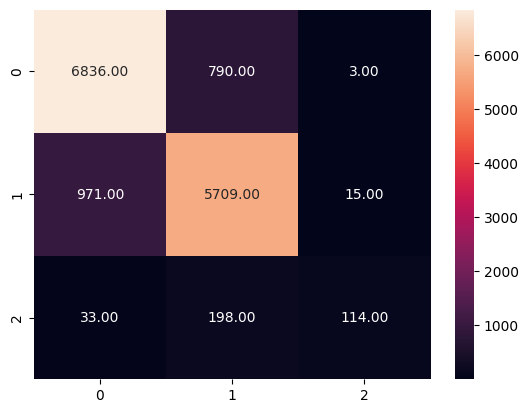

In [ ]:
sns.heatmap(confusion_matrix(y_test_encoded,xgb_pred),annot=True,fmt=".2f"
,xticklabels=xg_model.classes_,yticklabels=xg_model.classes_)

In [19]:
import joblib
joblib.dump(xgboost_model,'xgboost_model_room_type21.pkl')

['xgboost_model_room_type21.pkl']

In [20]:
loaded_xgboost_model = joblib.load('xgboost_model_room_type21.pkl')
print("Model loaded successfully!")

Model loaded successfully!
